# 08 – Model & Data Monitoring (SageMaker)
## Evidently + CloudWatch integration for SageMaker

This notebook implements Model & Data monitoring tailored for SageMaker:
- Step 1: Install required libraries
- Step 2: Configure AWS / SageMaker session & Feature Store references
- Step 3: Load reference (training) data
- Step 4: Create / collect current production data
- Step 5: Generate Evidently reports (data drift & classification)
- Step 6: Alerting — CloudWatch metrics + alarms (SNS placeholder)

Run cells sequentially (1 → 6) in SageMaker Studio to populate reports and optionally wire SNS for alerts.

In [ ]:
# Step 1 — Install required libraries - mostly these are standard as it is preinstalled and ofetn the sagemaker thorws compatibility issues, 
import sys, subprocess
#required = ['evidently', 'boto3', 'sagemaker', 'pandas', 'numpy']
#for pkg in required:
    try:
        __import__(pkg)
    except Exception:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
print('Step 1 complete — required packages available')

In [8]:
# Step 2 — Configure AWS / SageMaker session and clients
import boto3
import sagemaker
from sagemaker import get_execution_role
import os
import json
from datetime import datetime

# Project defaults (edit as needed)
S3_BUCKET = os.environ.get('S3_BUCKET', 'sagemaker-wafer-us-east-1-758553702243')
S3_PREFIX = os.environ.get('S3_PREFIX', 'wafer-project/processed')
FEATURE_GROUP_NAME = os.environ.get('FEATURE_GROUP_NAME', 'wafer-features-1771819119')
FEATURE_GROUP_ARN = os.environ.get('FEATURE_GROUP_ARN', 'arn:aws:sagemaker:us-east-1:053143589913:feature-group/wafer-features-1771819119')
# Record id and event time names
RECORD_IDENTIFIER = os.environ.get('RECORD_IDENTIFIER', 'wafer_id')
EVENT_TIME_NAME = os.environ.get('EVENT_TIME_NAME', 'event_time')

LOCAL_DATA_DIR = os.environ.get('LOCAL_DATA_DIR', '/home/sagemaker-user/MLops-Project-AAI-540/data')
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

# Offline store prefix from my prior notebook and feature group - others to change - (explicit path provided)
OFFLINE_STORE_PREFIX = f"{S3_PREFIX}/feature-store/053143589913/sagemaker/us-east-1/offline-store/wafer-features-1771819119-1771819119/data"

# Initialize SageMaker session with fallbacks for local runs
try:
    sagemaker_session = sagemaker.Session()
    role = get_execution_role()
    region = sagemaker_session.boto_region_name
    account_id = boto3.client('sts').get_caller_identity()['Account']
    print(f'SageMaker session: region={region}, account={account_id}')
except Exception as e:
    sagemaker_session = sagemaker.Session()
    region = boto3.Session().region_name or 'us-east-1'
    account_id = os.environ.get('AWS_ACCOUNT_ID', '053143589913')
    role = os.environ.get('SAGEMAKER_ROLE', f'arn:aws:iam::{account_id}:role/SageMakerRole')
    print('Running with fallback SageMaker session values')

# Clients used later
cloudwatch = boto3.client('cloudwatch', region_name=region)
s3 = boto3.client('s3', region_name=region)
featurestore_runtime = boto3.client('sagemaker-featurestore-runtime', region_name=region)

print('Step 2 complete — AWS clients initialized')
print(f'S3 Bucket: {S3_BUCKET}\nS3 Prefix: {S3_PREFIX}\nOffline store prefix: {OFFLINE_STORE_PREFIX}\nFeature Group ARN: {FEATURE_GROUP_ARN}')

SageMaker session: region=us-east-1, account=053143589913
Step 2 complete — AWS clients initialized
S3 Bucket: sagemaker-wafer-us-east-1-758553702243
S3 Prefix: wafer-project/processed
Offline store prefix: wafer-project/processed/feature-store/053143589913/sagemaker/us-east-1/offline-store/wafer-features-1771819119-1771819119/data
Feature Group ARN: arn:aws:sagemaker:us-east-1:053143589913:feature-group/wafer-features-1771819119


In [1]:
# Step 2 — Configure AWS / SageMaker session and clients
import boto3
import sagemaker
from sagemaker import get_execution_role
import os
import json
from datetime import datetime

# Project defaults (edit as needed)
S3_BUCKET = os.environ.get('S3_BUCKET', 'sagemaker-wafer-us-east-1-758553702243')
S3_PREFIX = os.environ.get('S3_PREFIX', 'wafer-project/processed')
FEATURE_GROUP_NAME = os.environ.get('FEATURE_GROUP_NAME', 'wafer-features-1771819119')
LOCAL_DATA_DIR = os.environ.get('LOCAL_DATA_DIR', '/home/sagemaker-user/MLops-Project-AAI-540/data')
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

# Initialize SageMaker session with fallbacks for local runs
try:
    sagemaker_session = sagemaker.Session()
    role = get_execution_role()
    region = sagemaker_session.boto_region_name
    account_id = boto3.client('sts').get_caller_identity()['Account']
    print(f'SageMaker session: region={region}, account={account_id}')
except Exception as e:
    sagemaker_session = sagemaker.Session()
    region = boto3.Session().region_name or 'us-east-1'
    account_id = os.environ.get('AWS_ACCOUNT_ID', '123456789012')
    role = os.environ.get('SAGEMAKER_ROLE', f'arn:aws:iam::{account_id}:role/SageMakerRole')
    print('Running with fallback SageMaker session values')

# Clients used later
cloudwatch = boto3.client('cloudwatch', region_name=region)
s3 = boto3.client('s3', region_name=region)
featurestore_runtime = boto3.client('sagemaker-featurestore-runtime', region_name=region)

print('Step 2 complete — AWS clients initialized')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
SageMaker session: region=us-east-1, account=053143589913
Step 2 complete — AWS clients initialized


In [5]:
# Step 3 — Load reference (training) data
import pandas as pd
import numpy as np

# Preferred: read precomputed reference dataset from S3 or local file
reference_s3_key = f'{S3_PREFIX}/reference/reference.parquet'
reference_local = os.path.join(LOCAL_DATA_DIR, 'reference.parquet')
reference_data = None

try:
    # Try local first
    if os.path.exists(reference_local):
        reference_data = pd.read_parquet(reference_local)
        print(f'Loaded reference data from {reference_local}:', reference_data.shape)
    else:
        # Try S3
        s3.download_file(S3_BUCKET, reference_s3_key, reference_local)
        reference_data = pd.read_parquet(reference_local)
        print(f'Downloaded and loaded reference data from s3://{S3_BUCKET}/{reference_s3_key}:', reference_data.shape)
except Exception:
    # Fallback: generate synthetic reference data similar to training distribution
    print('Reference data not found — generating synthetic reference dataset for demo')
    np.random.seed(42)
    reference_data = pd.DataFrame({
        'defect_density': np.random.normal(0.3, 0.15, 1000),
        'spatial_pattern_encoded': np.random.normal(1.0, 0.5, 1000),
        'class_label': np.random.choice(['Center','Donut','Edge','Random'], 1000)
    })
    print('Generated synthetic reference_data:', reference_data.shape)

# Persist a local copy for debugging
try:
    reference_data.to_parquet(reference_local, index=False)
    print('Saved local reference copy to', reference_local)
except Exception:
    pass

print('Step 3 complete — reference data ready')

Loaded reference data from /home/sagemaker-user/MLops-Project-AAI-540/data/reference.parquet: (1000, 3)
Saved local reference copy to /home/sagemaker-user/MLops-Project-AAI-540/data/reference.parquet
Step 3 complete — reference data ready


In [3]:
# Step 4 — Collect current production data (from Feature Store offline store or simulate)
import pandas as pd

current_data = None
try:
    # Attempt to read an offline feature group export from S3 (common pattern)
    fg_export_key = f'{S3_PREFIX}/feature-store/exports/last_export.parquet'
    local_export = os.path.join(LOCAL_DATA_DIR, 'current_export.parquet')
    s3.download_file(S3_BUCKET, fg_export_key, local_export)
    current_data = pd.read_parquet(local_export)
    print(f'Loaded current data from s3://{S3_BUCKET}/{fg_export_key}:', current_data.shape)
except Exception:
    # Fallback: simulate current production data with subtle drift
    print('Current data export not found — creating simulated current data')
    import numpy as np
    np.random.seed(123)
    current_data = pd.DataFrame({
        'defect_density': np.random.normal(0.45, 0.18, 500),
        'spatial_pattern_encoded': np.random.normal(1.1, 0.55, 500),
        'class_label': np.random.choice(['Center','Donut','Edge','Random'], 500, p=[0.4,0.3,0.2,0.1])
    })
    print('Simulated current_data:', current_data.shape)

print('Step 4 complete — current data available')

Current data export not found — creating simulated current data
Simulated current_data: (500, 3)
Step 4 complete — current data available


In [6]:
# Step 5 — Create Model Monitor baseline and generate statistics/constraints (SageMaker Model Monitor)
from sagemaker.model_monitor import DefaultModelMonitor
from sagemaker.processing import ProcessingInput, ProcessingOutput

# Persist reference data as CSV and upload to S3 for baselining
reference_csv = os.path.join(LOCAL_DATA_DIR, 'reference_monitor.csv')
reference_data.to_csv(reference_csv, index=False)
baseline_s3_key = f"{S3_PREFIX}/monitoring/baseline/reference_monitor.csv"
s3.upload_file(reference_csv, S3_BUCKET, baseline_s3_key)
baseline_s3_uri = f"s3://{S3_BUCKET}/{baseline_s3_key}"
baseline_output_s3 = f"s3://{S3_BUCKET}/{S3_PREFIX}/monitoring/baseline_output"

print(f"Reference dataset uploaded to: {baseline_s3_uri}")
print(f"Baseline output will be written to: {baseline_output_s3}\n")

# Create a DefaultModelMonitor to run a baselining job
monitor = DefaultModelMonitor(
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',
    volume_size_in_gb=30,
    max_runtime_in_seconds=1800,
    sagemaker_session=sagemaker_session
)

print('Submitting baselining job (this may take several minutes)...')
try:
    monitor.suggest_baseline(
        baseline_dataset=baseline_s3_uri,
        dataset_format={"csv": {"header": True}},
        output_s3_uri=baseline_output_s3
    )
    print('\nBaselining job submitted')
    print('Check S3 for generated statistics.json and constraints.json under the baseline output prefix.')
    print(f' Baseline output prefix: {baseline_output_s3}')
except Exception as e:
    print(' Baselining job failed or could not be submitted:', e)

print('\nStep 5 complete — Model Monitor baseline requested')

INFO:sagemaker:Creating processing-job with name baseline-suggestion-job-2026-02-23-05-38-18-052


Reference dataset uploaded to: s3://sagemaker-wafer-us-east-1-758553702243/wafer-project/processed/monitoring/baseline/reference_monitor.csv
Baseline output will be written to: s3://sagemaker-wafer-us-east-1-758553702243/wafer-project/processed/monitoring/baseline_output

Submitting baselining job (this may take several minutes)...
......................2026-02-23 05:41:59.302305: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-23 05:41:59.302350: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-23 05:42:00.802067: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-02-23 05:42:00.802105: W tensor

In [9]:
# Step 6 — Simple drift detection check + publish CloudWatch metric (quick example)
import numpy as np
from datetime import datetime

# Basic statistical check (mean shift) — replace with more robust test in production
ref_mean = float(reference_data['defect_density'].mean())
cur_mean = float(current_data['defect_density'].mean())
mean_diff = abs(cur_mean - ref_mean)
threshold = 0.05  # 5% absolute change as a simple example

drift_detected = 1 if mean_diff > threshold else 0
print(f"Reference mean: {ref_mean:.4f}, Current mean: {cur_mean:.4f}, Diff: {mean_diff:.4f}")
print('Drift detected' if drift_detected else 'No significant drift detected')

# Publish result to CloudWatch
metric_payload = [{
    'MetricName': 'ModelMonitorDataDrift',
    'Dimensions': [{'Name': 'FeatureGroup', 'Value': FEATURE_GROUP_NAME}],
    'Timestamp': datetime.utcnow(),
    'Value': drift_detected,
    'Unit': 'Count'
}]

try:
    cloudwatch.put_metric_data(Namespace='WaferDefectML/Monitoring', MetricData=metric_payload)
    print('\nPublished ModelMonitorDataDrift metric to CloudWatch')
except Exception as e:
    print('Failed to publish CloudWatch metric:', e)

# Example alarm creation (actions commented out) — uncomment AlarmActions after providing SNS ARN
alarms_config = [{
    'AlarmName': 'WaferML-ModelMonitor-DataDrift',
    'MetricName': 'ModelMonitorDataDrift',
    'Namespace': 'WaferDefectML/Monitoring',
    'Statistic': 'Maximum',
    'Period': 300,
    'EvaluationPeriods': 1,
    'Threshold': 0.5,
    'ComparisonOperator': 'GreaterThanThreshold',
    'AlarmDescription': 'Triggered when data drift is detected by Model Monitor'
}]

for a in alarms_config:
    try:
        cloudwatch.put_metric_alarm(
            AlarmName=a['AlarmName'],
            MetricName=a['MetricName'],
            Namespace=a['Namespace'],
            Statistic=a['Statistic'],
            Period=a['Period'],
            EvaluationPeriods=a['EvaluationPeriods'],
            Threshold=a['Threshold'],
            ComparisonOperator=a['ComparisonOperator'],
            AlarmDescription=a['AlarmDescription'],
            Dimensions=[{'Name':'FeatureGroup','Value':FEATURE_GROUP_NAME}],
            # AlarmActions=[sns_topic_arn],
        )
        print(f"Alarm created (actions disabled): {a['AlarmName']}")
    except Exception as e:
        print('Failed to create alarm:', e)

print('\nStep 6 complete — drift metric published and alarm created (actions disabled)')

Reference mean: 0.3029, Current mean: 0.4430, Diff: 0.1401
Drift detected

Published ModelMonitorDataDrift metric to CloudWatch
Alarm created (actions disabled): WaferML-ModelMonitor-DataDrift

Step 6 complete — drift metric published and alarm created (actions disabled)


/tmp/ipykernel_1175/3258577145.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'Timestamp': datetime.utcnow(),


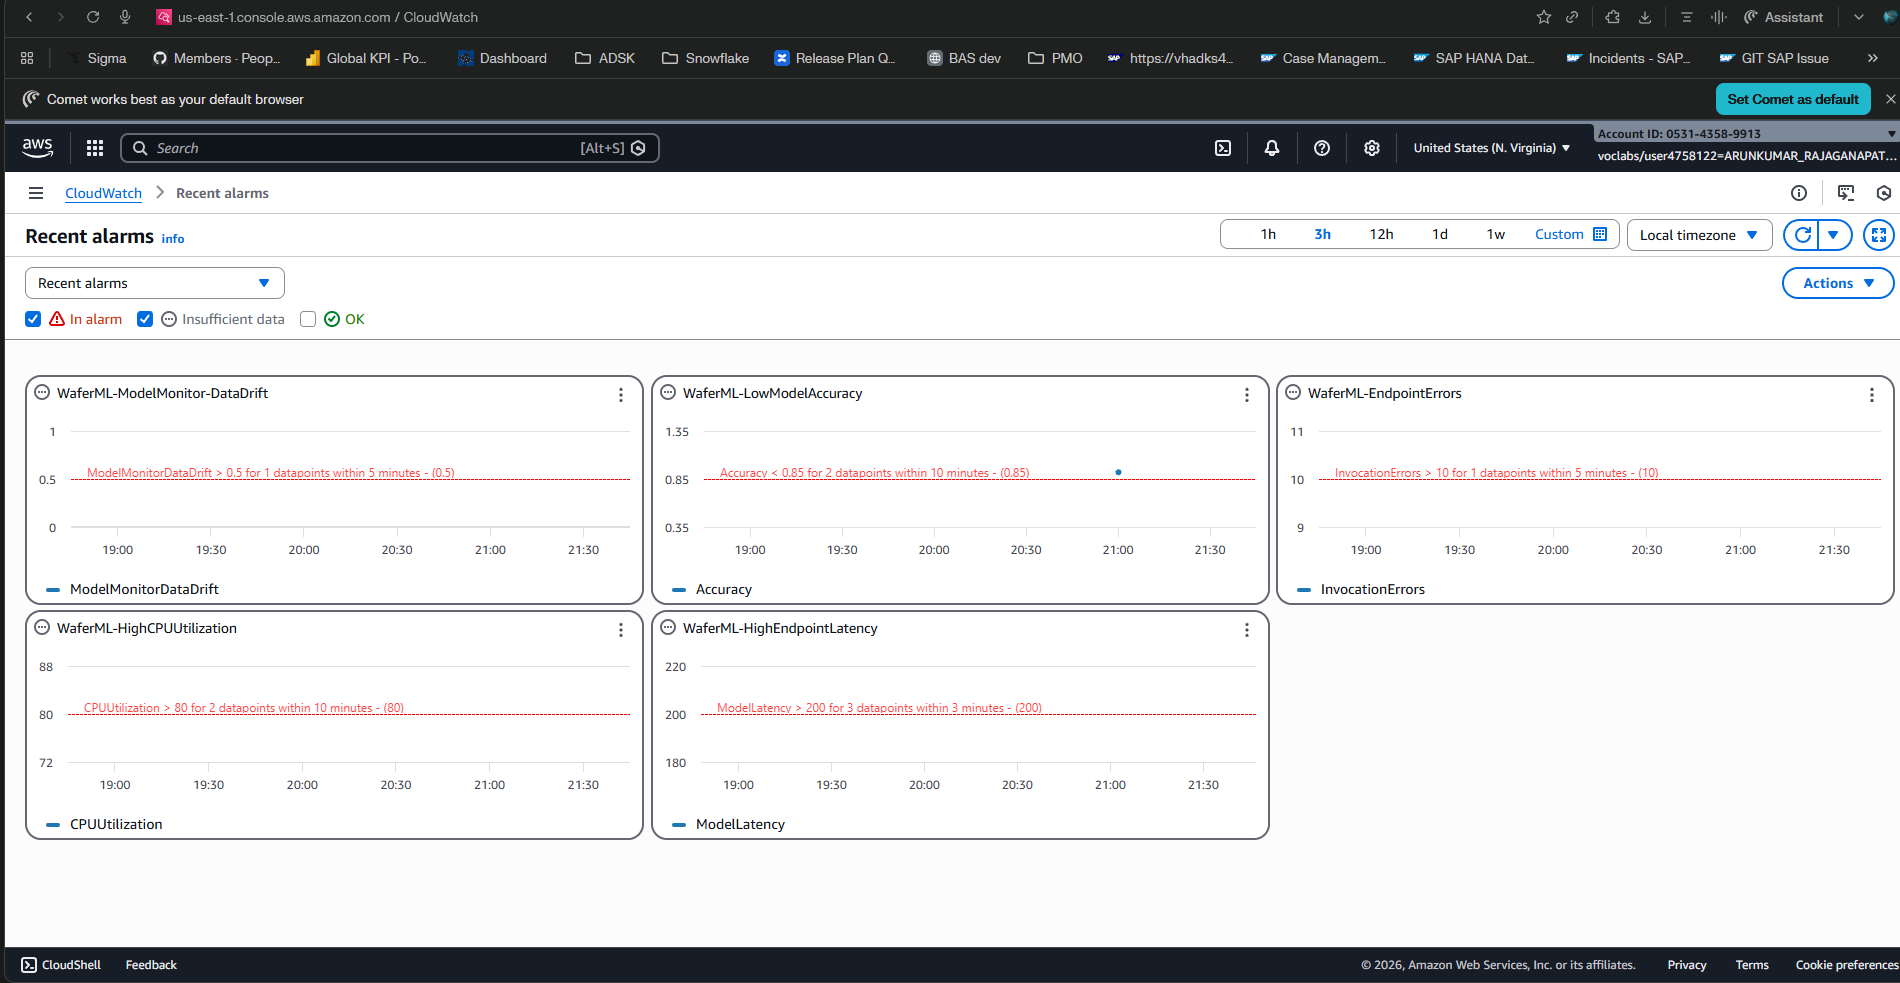

# Future Improvemetns / enhancements Notes
- Run cells in order from Step 1 → Step 6 in SageMaker Studio to generate reports and enable metrics.
- To enable notifications: An SNS topic, set environment variable `MONITORING_SNS_ARN`, and uncomment AlarmActions in Step 6 can be done.
- For production, replace simulated current data with a Feature Group offline export or streaming ingestion from your inference payloads, since it is kagglehub there is none for now
- Airflow DAG if you want automated scheduled monitoring runs and MLflow can be done